In [1]:
# ============================================================
# Cell 0 - Import Packages and Load BTMS Model
# ============================================================

import os
import sys
import io
import re
import contextlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.BTMS_model as BTMS_model

# Always reload the latest BTMS_model.py.
BTMS_model = importlib.reload(BTMS_model)

print(f'Project root: {PROJECT_ROOT}')
print(f'BTMS_model loaded from: {BTMS_model.__file__}')


Project root: d:\eBATS
BTMS_model loaded from: d:\eBATS\lib\BTMS_model.py


In [2]:
# ============================================================
# Cell 1 - Result-File Naming Configuration
# ============================================================

# [RESULTID]_[SCN]_[BTMS]_[MODEL]_[TASK].[ext]
# This notebook evaluates the final LC-PARK design selected from C0003R03.

CASE_ID = 'C0009'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULT_FIGURE_NAME = f'{RESULT_BASENAME}_CFD_COMPARE.png'

# CFD comparison data for C0009.
# Put the following Fluent report files in:
#   data/C0009/max-rfile.out
#   data/C0009/min-rfile.out
ENABLE_CFD_COMPARISON = True

CFD_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    'data',
    CASE_ID,
)

CFD_FILES = {
    'CFD_max': 'max-rfile.out',
    'CFD_min': 'min-rfile.out',
}

print(f'Result basename: {RESULT_BASENAME}')
print(f'Notebook file: {NOTEBOOK_NAME}')
print(f'CFD data directory: {CFD_DATA_DIR}')
print(f'CFD comparison enabled: {ENABLE_CFD_COMPARISON}')


Result basename: C0009R01_PARK25_LC_1D_EVAL
Notebook file: C0009R01_PARK25_LC_1D_EVAL.ipynb
CFD data directory: d:\eBATS\data\C0009
CFD comparison enabled: True


In [3]:
# ============================================================
# Cell 2 - Load Battery Heat-Generation Data
# ============================================================

SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                  # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original downstream variable name.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    PROJECT_ROOT,
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx',
)

if not os.path.isfile(file_name):
    raise FileNotFoundError(
        f'Heat-generation data file not found: {file_name}\n'
        'Place the Excel file in the project data folder.'
    )

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

# Source Qbat data are 1-s samples.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')


Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [4]:
# ============================================================
# Cell 3 - Model Settings and LC-PARK Evaluation Conditions
# ============================================================

BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}

MODULE_LAYOUT = {
    'N_r': 20,               # control volumes along coolant-flow direction
    'N_c': 16,               # battery columns in transverse direction
}

LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,
    'W_channel': 10.0e-3,
    'H_channel': 3.0e-3,
    'L_channel': 0.380,
    'W_battery': 16 * 18.0e-3,
    'S_min': 1.0e-3,
    'delta_plate_coolant': 2.0e-3,
    'k_plate': 200.0,
    'rho_plate': 2719.0,
    'pump_efficiency': 0.35,
    'K_minor': 0.0,
    'm_pump': 0.0,
    'm_pipe': 0.0,
}

# Final design selected from C0003R03.
SELECTED_CONDITION = {
    'case_id': f'{CASE_ID}_S001',
    'T_water': 25.0,
    'm_dot_total': 0.045,
    'num_parallel_channels': 32,
    'W_channel_case': 10.0e-3,
    'H_channel_case': 3.0e-3,
    'L_channel_case': 0.380,
    'S_channel_fixed': None,
}

# Baseline design from C0002R01_PARK25_LC_1D_VAL.
# The C0002 operating/geometry parameters are evaluated here with the latest C0009 calculation logic.
BASELINE_CONDITION = {
    'case_id': f'{RESULT_ID}_BASELINE',
    'T_water': 25.0,
    'm_dot_total': 0.06106836,
    'num_parallel_channels': 20,
    'W_channel_case': 8.0e-3,
    'H_channel_case': 3.0e-3,
    'L_channel_case': 0.380,
    'S_channel_fixed': 17.77e-3,
}

SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

mission_stages = [
    ('takeoff',       0.0,    6.0),
    ('climb',         6.0,   36.0),
    ('transition1',  36.0,  180.0),
    ('cruise',      180.0, 1560.0),
    ('transition2',1560.0, 1704.0),
    ('descent',    1704.0, 1734.0),
    ('hover',      1734.0, 1914.0),
    ('landing',    1914.0, 1920.0),
]

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat
N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r
fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']
W_channel = LIQUID_SETTINGS['W_channel']
H_channel = LIQUID_SETTINGS['H_channel']
L_channel = LIQUID_SETTINGS['L_channel']
W_battery = LIQUID_SETTINGS['W_battery']
S_min = LIQUID_SETTINGS['S_min']
delta_plate_coolant = LIQUID_SETTINGS['delta_plate_coolant']
k_plate = LIQUID_SETTINGS['k_plate']
rho_plate = LIQUID_SETTINGS['rho_plate']
pump_efficiency = LIQUID_SETTINGS['pump_efficiency']
K_minor = LIQUID_SETTINGS['K_minor']
m_pump = LIQUID_SETTINGS['m_pump']
m_pipe = LIQUID_SETTINGS['m_pipe']
pump_operation_time = SIM_DURATION_S
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

SELECTED_CONDITION['num_cell_seg'] = N_c / SELECTED_CONDITION['num_parallel_channels']
BASELINE_CONDITION['num_cell_seg'] = N_c / BASELINE_CONDITION['num_parallel_channels']

num_parallel_channels_selected = SELECTED_CONDITION['num_parallel_channels']
num_spacing_intervals_selected = num_parallel_channels_selected + 1
W_plate_spacing_limit_selected = num_parallel_channels_selected * SELECTED_CONDITION['W_channel_case'] + num_spacing_intervals_selected * S_min
W_plate_selected = max(W_battery, W_plate_spacing_limit_selected)
S_channel_selected = (W_plate_selected - num_parallel_channels_selected * SELECTED_CONDITION['W_channel_case']) / num_spacing_intervals_selected

num_parallel_channels_baseline = BASELINE_CONDITION['num_parallel_channels']
num_spacing_intervals_baseline = num_parallel_channels_baseline + 1
W_plate_baseline = num_parallel_channels_baseline * BASELINE_CONDITION['W_channel_case'] + num_spacing_intervals_baseline * BASELINE_CONDITION['S_channel_fixed']

print('Final selected LC-PARK condition:')
print(f"  T_water = {SELECTED_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {SELECTED_CONDITION['m_dot_total']:.3f} kg/s")
print(f"  N_ch = {SELECTED_CONDITION['num_parallel_channels']}")
print(f"  W_channel = {SELECTED_CONDITION['W_channel_case'] * 1e3:.2f} mm")
print(f"  H_channel = {SELECTED_CONDITION['H_channel_case'] * 1e3:.2f} mm")
print(f"  L_channel = {SELECTED_CONDITION['L_channel_case'] * 1e3:.2f} mm")
print(f"  S_channel = {S_channel_selected * 1e3:.2f} mm")
print(f"  W_plate = {W_plate_selected * 1e3:.2f} mm")
print(f"  num_cell_seg = {SELECTED_CONDITION['num_cell_seg']:.4f}")
print()
print('C0002 baseline LC-PARK condition:')
print(f"  T_water = {BASELINE_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {BASELINE_CONDITION['m_dot_total']:.8f} kg/s")
print(f"  N_ch = {BASELINE_CONDITION['num_parallel_channels']}")
print(f"  W_channel = {BASELINE_CONDITION['W_channel_case'] * 1e3:.2f} mm")
print(f"  H_channel = {BASELINE_CONDITION['H_channel_case'] * 1e3:.2f} mm")
print(f"  L_channel = {BASELINE_CONDITION['L_channel_case'] * 1e3:.2f} mm")
print(f"  S_channel = {BASELINE_CONDITION['S_channel_fixed'] * 1e3:.2f} mm")
print(f"  W_plate = {W_plate_baseline * 1e3:.2f} mm")
print(f"  num_cell_seg = {BASELINE_CONDITION['num_cell_seg']:.4f}")



Final selected LC-PARK condition:
  T_water = 25.0 degC
  m_dot_total = 0.045 kg/s
  N_ch = 32
  W_channel = 10.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  S_channel = 1.00 mm
  W_plate = 353.00 mm
  num_cell_seg = 0.5000

C0002 baseline LC-PARK condition:
  T_water = 25.0 degC
  m_dot_total = 0.06106836 kg/s
  N_ch = 20
  W_channel = 8.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  S_channel = 17.77 mm
  W_plate = 533.17 mm
  num_cell_seg = 0.8000


In [5]:
# ============================================================
# Cell 4 - Build the Selected and Baseline Cases
# ============================================================

single_case = {
    'case_id': SELECTED_CONDITION['case_id'],
    'T_water': float(SELECTED_CONDITION['T_water']),
    'm_dot_total': float(SELECTED_CONDITION['m_dot_total']),
    'num_cell_seg': float(SELECTED_CONDITION['num_cell_seg']),
    'W_channel_case': float(SELECTED_CONDITION['W_channel_case']),
    'H_channel_case': float(SELECTED_CONDITION['H_channel_case']),
    'L_channel_case': float(SELECTED_CONDITION['L_channel_case']),
    'S_channel_fixed': SELECTED_CONDITION['S_channel_fixed'],
}

baseline_case = {
    'case_id': BASELINE_CONDITION['case_id'],
    'T_water': float(BASELINE_CONDITION['T_water']),
    'm_dot_total': float(BASELINE_CONDITION['m_dot_total']),
    'num_cell_seg': float(BASELINE_CONDITION['num_cell_seg']),
    'W_channel_case': float(BASELINE_CONDITION['W_channel_case']),
    'H_channel_case': float(BASELINE_CONDITION['H_channel_case']),
    'L_channel_case': float(BASELINE_CONDITION['L_channel_case']),
    'S_channel_fixed': float(BASELINE_CONDITION['S_channel_fixed']),
}

print('Selected case:')
print(single_case)
print('Baseline case:')
print(baseline_case)



Selected case:
{'case_id': 'C0009_S001', 'T_water': 25.0, 'm_dot_total': 0.045, 'num_cell_seg': 0.5, 'W_channel_case': 0.01, 'H_channel_case': 0.003, 'L_channel_case': 0.38, 'S_channel_fixed': None}
Baseline case:
{'case_id': 'C0009R01_BASELINE', 'T_water': 25.0, 'm_dot_total': 0.06106836, 'num_cell_seg': 0.8, 'W_channel_case': 0.008, 'H_channel_case': 0.003, 'L_channel_case': 0.38, 'S_channel_fixed': 0.01777}


In [6]:
# ============================================================
# Cell 5 - Calculate Water Properties for All Inlet Temperatures
# ============================================================

water_props_cache = {}
case_temperatures = sorted({float(single_case['T_water']), float(baseline_case['T_water'])})

for T_water_case in case_temperatures:
    T_water_K = T_water_case + 273.15
    mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
    rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
    cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
    k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
    Pr_water = cp_water * mu_water / k_water
    water_props_cache[T_water_case] = {'mu_water': mu_water, 'rho_water': rho_water, 'cp_water': cp_water, 'k_water': k_water, 'Pr_water': Pr_water}
    print(f'Water properties calculated at T_water = {T_water_case:.1f} degC.')



Water properties calculated at T_water = 25.0 degC.


In [7]:
# ============================================================
# Cell 6 - Run the Selected Single Case
# Latest calculation logic aligned with C0003R03
# ============================================================

def run_one_case(case_id, T_water, m_dot_total, num_cell_seg, W_channel_case, H_channel_case, L_channel_case, S_channel_fixed=None):
    water_props = water_props_cache[float(T_water)]
    W_channel = float(W_channel_case)
    H_channel = float(H_channel_case)
    L_channel = float(L_channel_case)

    if m_dot_total <= 0:
        raise ValueError('m_dot_total must be positive.')
    if num_cell_seg <= 0:
        raise ValueError('num_cell_seg must be positive.')

    # ---------------------------------------------------------
    # Number of parallel channels and per-channel mass flow rate
    # ---------------------------------------------------------
    num_parallel_channels_float = N_c / num_cell_seg
    num_parallel_channels = int(round(num_parallel_channels_float))

    if not np.isclose(num_parallel_channels, num_parallel_channels_float):
        raise ValueError(
            f'num_cell_seg={num_cell_seg} does not produce '
            'an integer channel count.'
        )

    # ---------------------------------------------------------
    # Cold-plate transverse geometry: same as C0003R03
    # ---------------------------------------------------------
    num_spacing_intervals = num_parallel_channels + 1
    if S_channel_fixed is None:
        W_plate_spacing_limit = num_parallel_channels * W_channel + num_spacing_intervals * S_min
        W_plate = max(W_battery, W_plate_spacing_limit)
        S_channel_case = (W_plate - num_parallel_channels * W_channel) / num_spacing_intervals
    else:
        S_channel_case = float(S_channel_fixed)
        W_plate = num_parallel_channels * W_channel + num_spacing_intervals * S_channel_case

    tol = 1e-12
    if W_plate < W_battery - tol:
        raise RuntimeError('Cold-plate width is smaller than the battery-array width.')
    if S_channel_case < S_min - tol:
        raise RuntimeError('Channel spacing is below the minimum 1 mm.')

    # Total flow is divided equally among parallel channels.
    m_dot_channel = m_dot_total / num_parallel_channels

    # ---------------------------------------------------------
    # Rectangular-channel geometry and heat transfer
    # ---------------------------------------------------------
    A_cool_cs = W_channel * H_channel
    Dh = 2.0 * W_channel * H_channel / (W_channel + H_channel)
    A_HT_seg = (W_channel + 2.0 * H_channel) * L_channel / num_seg

    u_water = m_dot_channel / (water_props['rho_water'] * A_cool_cs)
    Re_water = (
        water_props['rho_water']
        * u_water
        * Dh
        / water_props['mu_water']
    )

    Nu_water = BTMS_model.liquid_nusselt_number_rect_channel(
        W_channel,
        H_channel,
    )
    h_water = Nu_water * water_props['k_water'] / Dh
    R_plate = delta_plate_coolant / k_plate
    htc_global = 1.0 / (1.0 / h_water + R_plate)
    htc_cool = np.ones(num_seg) * htc_global

    # ---------------------------------------------------------
    # Pump power: pressure drop from one representative channel,
    # total pump power from the complete system mass flow rate.
    # ---------------------------------------------------------
    f_water = BTMS_model.cal_friction_factor_rect_channel(
        Re_water,
        W_channel,
        H_channel,
    )

    pump_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'mu_cool': water_props['mu_water'],
        'A_cool_cs': A_cool_cs,
        'D_channel': Dh,
        'L_channel': L_channel,
        'm_dot_total': m_dot_total,
        'num_channel': num_parallel_channels,
        'pump_efficiency': pump_efficiency,
        'K_minor': K_minor,
        'operation_time': pump_operation_time,
    }

    pump_results = BTMS_model.cal_btms_aux_power(
        pump_args,
        friction_factor=f_water,
    )
    P_pump = float(pump_results['P_aux_W'])
    E_pump_cumulative = float(pump_results['E_aux_J'])

    if not np.isclose(
        pump_results['Re'],
        Re_water,
        rtol=1e-12,
        atol=0.0,
    ):
        raise RuntimeError(
            'Inconsistent Reynolds number in pump-power calculation.'
        )

    # ---------------------------------------------------------
    # Full liquid-cooling BTMS mass: same logic as C0003R03
    # ---------------------------------------------------------
    mass_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'rho_plate': rho_plate,
        'L_channel': L_channel,
        'W_plate': W_plate,
        'A_cool_cs': A_cool_cs,
        'H_channel': H_channel,
        'H_bottom': delta_plate_coolant,
        'num_channel': num_parallel_channels,
        'm_pump': m_pump,
        'm_pipe': m_pipe,
        'return_components': True,
    }

    mass_results = BTMS_model.cal_btms_mass(mass_args)
    mtotal = float(mass_results['m_BTMS_kg'])

    mass_component_sum = (
        mass_results['m_plate_kg']
        + mass_results['m_coolant_kg']
        + mass_results['m_pump_kg']
        + mass_results['m_pipe_kg']
    )

    if not np.isclose(
        mtotal,
        mass_component_sum,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            'Inconsistent component sum in BTMS mass calculation.'
        )

    # Initial battery and coolant temperatures equal inlet temperature.
    T_bat = np.ones(num_seg) * T_water
    T_cool = np.ones(num_seg) * T_water

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_water_history[0, :] = T_cool

    # ---------------------------------------------------------
    # Full-mission transient solution
    # ---------------------------------------------------------
    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = True

        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': u_water,
            'p_cool': p_water,
            'fluid_cool': fluid,
            'A_HT_seg': A_HT_seg,
            'A_cool_cs': A_cool_cs,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_water,
            'T_cool_out': max(float(T_cool[-1]), T_water),
            'is_cool': is_cool,
            'htc_cool': htc_cool,
            'cp_cool': water_props['cp_water'],
            'rho_cool': water_props['rho_water'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(
                    args,
                    tol=solver_tol,
                    maxiter=solver_maxiter,
                    debug=False,
                )
        except Exception as e:
            print('\nSolver failed inside run_one_case.')
            print(f'case_id = {case_id}')
            print(f'm_dot_total = {m_dot_total} kg/s')
            print(f'm_dot_channel = {m_dot_channel} kg/s')
            print(f'num_parallel_channels = {num_parallel_channels}')
            print(f'T_water_in = {T_water} degC')
            print(f'W_plate = {W_plate * 1e3} mm')
            print(f'S_channel = {S_channel_case * 1e3} mm')
            print(f'Dh = {Dh * 1e3} mm')
            print(f'num_cell_seg = {num_cell_seg}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'u_water = {u_water}')
            print(f'Re_water = {Re_water}')
            print(f'Nu_water = {Nu_water}')
            print(f'h_water = {h_water}')
            print(f'htc_global = {htc_global}')
            print(f'A_HT_seg = {A_HT_seg}')
            print(f'A_cool_cs = {A_cool_cs}')
            print(f'P_pump = {P_pump}')
            print(f'E_pump_cumulative = {E_pump_cumulative}')
            print(f'mtotal = {mtotal}')
            print(
                'T_bat_min/max before solve = '
                f'{np.min(T_bat)}, {np.max(T_bat)}'
            )
            print(
                'T_cool_min/max before solve = '
                f'{np.min(T_cool)}, {np.max(T_cool)}'
            )
            print(f'solver_tol = {solver_tol}')
            print(f'solver_maxiter = {solver_maxiter}')
            print(f'error = {repr(e)}')
            raise

        if not np.all(np.isfinite(T_dist)):
            print('\nSolver returned non-finite values.')
            print(f'case_id = {case_id}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(
                'T_dist_min/max = '
                f'{np.nanmin(T_dist)}, {np.nanmax(T_dist)}'
            )
            raise FloatingPointError('Non-finite values detected in T_dist')

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat
        T_water_history[k + 1, :] = T_cool

    # ---------------------------------------------------------
    # Mission indicators
    # ---------------------------------------------------------
    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Twater_out = T_water_history[:, -1]

    cruise_end_time = next(
        t1
        for stage_name, _, t1 in mission_stages
        if stage_name == 'cruise'
    )

    def idx(t_value):
        return int(round(t_value / dt))

    row = {
        'case_id': case_id,
        'T_water_in_C': float(T_water),
        'm_dot_total_kg_s': float(m_dot_total),
        'm_dot_channel_kg_s': float(m_dot_channel),
        'num_cell_seg': float(num_cell_seg),
        'num_parallel_channels': int(num_parallel_channels),
        'W_channel_mm': float(W_channel * 1e3),
        'H_channel_mm': float(H_channel * 1e3),
        'L_channel_mm': float(L_channel * 1e3),
        'W_plate_mm': float(W_plate * 1e3),
        'S_channel_mm': float(S_channel_case * 1e3),
        'spacing_mode': 'fixed' if S_channel_fixed is not None else 'auto',
        'H_plate_mm': float((H_channel + delta_plate_coolant) * 1e3),
        'Dh_mm': float(Dh * 1e3),
        'u_water_m_s': float(u_water),
        'Re_water': float(Re_water),
        'Nu_water': float(Nu_water),
        'h_water_W_m2K': float(h_water),
        'htc_global_W_m2K': float(htc_global),
        'P_pump': P_pump,
        'E_pump_cumulative': E_pump_cumulative,
        'm_plate_kg': float(mass_results['m_plate_kg']),
        'm_coolant_kg': float(mass_results['m_coolant_kg']),
        'mtotal': mtotal,
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(np.max(DeltaT)),
        'Twater_out_cruise_end_C': float(Twater_out[idx(cruise_end_time)]),
    }

    for stage_name, t0, t1 in mission_stages:
        row[f'dTmax_{stage_name}_C'] = float(
            Tmax[idx(t1)] - Tmax[idx(t0)]
        )

    histories = {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax.copy(),
        'Tmin_C': Tmin.copy(),
        'DeltaT_C': DeltaT.copy(),
        'Twater_out_C': Twater_out.copy(),
        'T_bat_history_C': T_bat_history.copy(),
        'T_water_history_C': T_water_history.copy(),
    }

    return row, histories



In [8]:
# ============================================================
# Cell 7 - Run Selected and Baseline Cases
# ============================================================

print('Running final selected LC-PARK condition...')
summary_row, histories = run_one_case(**single_case)
print('Selected condition completed.')
print()
print('Running C0002 baseline condition with the latest C0009 calculation logic...')
baseline_summary_row, baseline_histories = run_one_case(**baseline_case)
print('Baseline condition completed.')

# ------------------------------------------------------------
# Read Fluent temperature-history report files from data/C0009
# CFD data correspond to the selected C0009 condition only.
# ------------------------------------------------------------
def read_fluent_temperature_history(file_path):
    rows = []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            tokens = re.sub(r'[(),]', ' ', line.strip()).split()
            try:
                values = [float(token) for token in tokens]
            except ValueError:
                continue
            if len(values) >= 3:
                rows.append([values[-1], values[-2]])
            elif len(values) == 2:
                rows.append([values[0], values[1]])
    if not rows:
        raise ValueError(f'No numeric CFD history found in: {file_path}')
    data = np.asarray(rows, dtype=float)
    time_cfd = data[:, 0]
    temperature_cfd = data[:, 1]
    if np.nanmedian(temperature_cfd) > 150.0:
        temperature_cfd = temperature_cfd - 273.15
    order = np.argsort(time_cfd)
    return time_cfd[order], temperature_cfd[order]

cfd_histories = {}
if ENABLE_CFD_COMPARISON:
    for line_name, file_name in CFD_FILES.items():
        file_path = os.path.join(CFD_DATA_DIR, file_name)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f'CFD comparison is enabled but file was not found: {file_path}\nPlease place {file_name} in data/{CASE_ID}/.')
        cfd_histories[line_name] = read_fluent_temperature_history(file_path)
        time_cfd, temperature_cfd = cfd_histories[line_name]
        print(f'{line_name}: {len(time_cfd)} points, t = {time_cfd[0]:.1f}-{time_cfd[-1]:.1f} s, T = {np.min(temperature_cfd):.3f}-{np.max(temperature_cfd):.3f} degC')

# ------------------------------------------------------------
# Print selected and baseline results.
# ------------------------------------------------------------
print()
print('Final selected-condition geometry/results:')
print(f"  N_ch = {summary_row['num_parallel_channels']}")
print(f"  W_channel = {summary_row['W_channel_mm']:.3f} mm")
print(f"  H_channel = {summary_row['H_channel_mm']:.3f} mm")
print(f"  L_channel = {summary_row['L_channel_mm']:.3f} mm")
print(f"  W_plate = {summary_row['W_plate_mm']:.3f} mm")
print(f"  S_channel = {summary_row['S_channel_mm']:.3f} mm")
print(f"  Tmax = {summary_row['Tmax_mission_C']:.3f} degC")
print(f"  DeltaTmax = {summary_row['DeltaT_mission_max_C']:.3f} degC")
print(f"  P_pump,total = {summary_row['P_pump']:.6f} W")
print(f"  E_pump = {summary_row['E_pump_cumulative']:.3f} J")
print(f"  m_total = {summary_row['mtotal']:.5f} kg")
print()
print('C0002 baseline geometry/results evaluated with C0009 logic:')
print(f"  N_ch = {baseline_summary_row['num_parallel_channels']}")
print(f"  W_channel = {baseline_summary_row['W_channel_mm']:.3f} mm")
print(f"  H_channel = {baseline_summary_row['H_channel_mm']:.3f} mm")
print(f"  L_channel = {baseline_summary_row['L_channel_mm']:.3f} mm")
print(f"  W_plate = {baseline_summary_row['W_plate_mm']:.3f} mm")
print(f"  S_channel = {baseline_summary_row['S_channel_mm']:.3f} mm")
print(f"  Tmax = {baseline_summary_row['Tmax_mission_C']:.3f} degC")
print(f"  DeltaTmax = {baseline_summary_row['DeltaT_mission_max_C']:.3f} degC")
print(f"  P_pump,total = {baseline_summary_row['P_pump']:.6f} W")
print(f"  E_pump = {baseline_summary_row['E_pump_cumulative']:.3f} J")
print(f"  m_total = {baseline_summary_row['mtotal']:.5f} kg")

if ENABLE_CFD_COMPARISON:
    time_cfd_max, temperature_cfd_max = cfd_histories['CFD_max']
    time_cfd_min, temperature_cfd_min = cfd_histories['CFD_min']
    print()
    print('CFD comparison data correspond to the selected C0009 condition only.')
    print(f'  max-rfile.out: peak = {np.max(temperature_cfd_max):.3f} degC')
    print(f'  min-rfile.out: peak = {np.max(temperature_cfd_min):.3f} degC')



Running final selected LC-PARK condition...
Selected condition completed.

Running C0002 baseline condition with the latest C0009 calculation logic...
Baseline condition completed.
CFD_max: 1921 points, t = 0.0-1920.0 s, T = 25.000-37.001 degC
CFD_min: 1921 points, t = 0.0-1920.0 s, T = 25.000-34.152 degC

Final selected-condition geometry/results:
  N_ch = 32
  W_channel = 10.000 mm
  H_channel = 3.000 mm
  L_channel = 380.000 mm
  W_plate = 353.000 mm
  S_channel = 1.000 mm
  Tmax = 36.134 degC
  DeltaTmax = 3.189 degC
  P_pump,total = 0.003372 W
  E_pump = 6.474 J
  m_total = 1.19547 kg

C0002 baseline geometry/results evaluated with C0009 logic:
  N_ch = 20
  W_channel = 8.000 mm
  H_channel = 3.000 mm
  L_channel = 380.000 mm
  W_plate = 533.170 mm
  S_channel = 17.770 mm
  Tmax = 37.636 degC
  DeltaTmax = 1.363 degC
  P_pump,total = 0.013190 W
  E_pump = 25.325 J
  m_total = 2.44033 kg

CFD comparison data correspond to the selected C0009 condition only.
  max-rfile.out: peak = 3

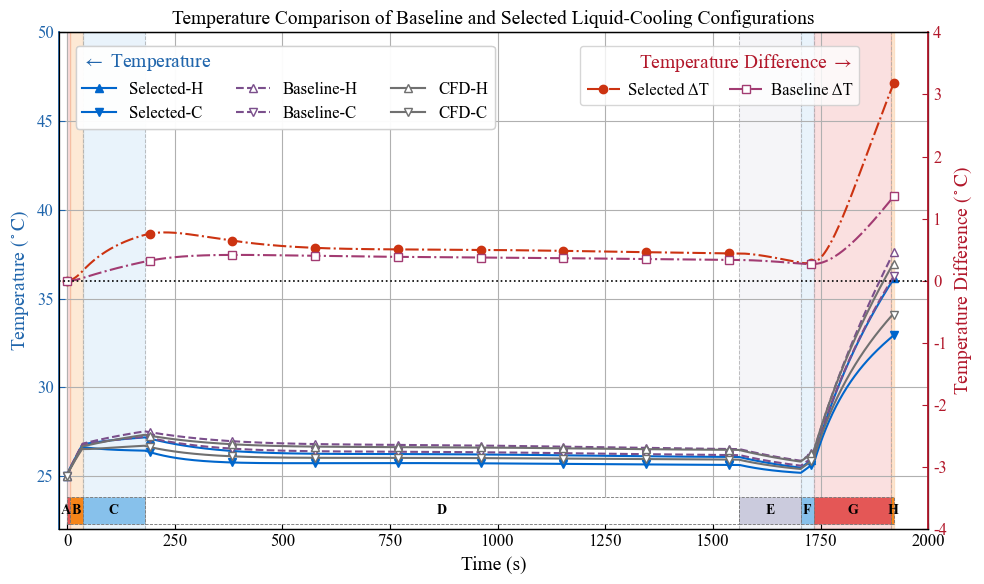

Saved comparison figure: d:\eBATS\out\C0009\C0009R01_PARK25_LC_1D_EVAL_CFD_COMPARE.png
Saved comparison figure: d:\eBATS\out\C0009\C0009R01_PARK25_LC_1D_EVAL_CFD_COMPARE.pdf


In [9]:
# ============================================================
# Cell 8 - Plot Selected/Baseline 1D and CFD Comparison
# ============================================================

from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory

figure_path = os.path.join(OUTPUT_DIR, RESULT_FIGURE_NAME)
figure_path_pdf = os.path.splitext(figure_path)[0] + '.pdf'
font_size = 12
stage_boundaries = [stage[2] for stage in mission_stages]
stage_names = ['A: Take-off', 'B: Ascent Transition', 'C: Acceleration', 'D: Cruise', 'E: Deceleration', 'F: Descent Transition', 'G: Hovering', 'H: Landing']
stages_bgcolors = ['#E45756', '#F58518', '#87c1eb', '#FFFFFF', '#CBCBDD', '#87c1eb', '#E45756', '#F58518']

plt.rcdefaults()
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'stix', 'font.size': font_size, 'axes.labelsize': font_size, 'axes.titlesize': font_size, 'xtick.labelsize': font_size, 'ytick.labelsize': font_size, 'axes.linewidth': 0.9, 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.major.width': 0.8, 'ytick.major.width': 0.8, 'xtick.major.size': 4, 'ytick.major.size': 4, 'axes.unicode_minus': False})

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(-20, 2000)

all_temp_min = min(np.min(histories['Tmin_C']), np.min(baseline_histories['Tmin_C']))
all_temp_max = max(np.max(histories['Tmax_C']), np.max(baseline_histories['Tmax_C']))
if ENABLE_CFD_COMPARISON:
    all_temp_min = min(all_temp_min, np.min(cfd_histories['CFD_min'][1]), np.min(cfd_histories['CFD_max'][1]))
    all_temp_max = max(all_temp_max, np.max(cfd_histories['CFD_min'][1]), np.max(cfd_histories['CFD_max'][1]))
y_min = min(22.0, np.floor(all_temp_min) - 1.0)
y_max = max(50.0, np.ceil(all_temp_max) + 1.0)
ax1.set_ylim(y_min, y_max)

alpha_band = 0.18
for i in range(len(stage_boundaries)):
    t_start = 0.0 if i == 0 else stage_boundaries[i - 1]
    t_end = stage_boundaries[i]
    ax1.axvspan(t_start, t_end, color=stages_bgcolors[i], alpha=alpha_band, zorder=0)

for boundary in stage_boundaries[1:-1]:
    ax1.axvline(boundary, color='0.65', linewidth=0.7, linestyle='--', alpha=0.7, zorder=1)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
bar_bottom = 0.01
bar_height = 0.055
for i, name in enumerate(stage_names):
    t_start = 0.0 if i == 0 else stage_boundaries[i - 1]
    t_end = stage_boundaries[i]
    t_mid = 0.5 * (t_start + t_end)
    duration = t_end - t_start
    offset = 5.0 if i == 0 else 0.0
    rect = Rectangle((t_start, bar_bottom), duration, bar_height, transform=trans, facecolor=stages_bgcolors[i], edgecolor='0.45', linewidth=0.6, linestyle='--', clip_on=False, zorder=10, alpha=1.0)
    ax1.add_patch(rect)
    ax1.text(t_mid - offset, bar_bottom + 0.5 * bar_height, name.split(':')[0], transform=trans, ha='center', va='center', rotation=0, fontsize=font_size - 2, fontweight='bold', color='black', clip_on=False, zorder=11)

left_style = {'1D_MIN': dict(label='Selected-C', color='#0066CC', ls='-', marker='v'), '1D_MAX': dict(label='Selected-H', color='#0066CC', ls='-', marker='^'), 'BASELINE_MIN': dict(label='Baseline-C', color='#7B4F8C', ls='--', marker='v', markerfacecolor='white'), 'BASELINE_MAX': dict(label='Baseline-H', color='#7B4F8C', ls='--', marker='^', markerfacecolor='white'), 'CFD_MIN': dict(label='CFD-C', color='#707070', ls='-', marker='v', markerfacecolor='white'), 'CFD_MAX': dict(label='CFD-H', color='#707070', ls='-', marker='^', markerfacecolor='white')}
right_style = {'DELTA_1D': dict(label='Selected ΔT', color='#CC3311', ls='-.', marker='o'), 'DELTA_BASELINE': dict(label='Baseline ΔT', color='#A23B72', ls='-.', marker='s', markerfacecolor='white')}
left_color = '#2166AC'
right_color = '#B2182B'
mark_number = 10
mark_spacing_1d = max(1, len(histories['time_s']) // mark_number)
mark_spacing_baseline = max(1, len(baseline_histories['time_s']) // mark_number)

ax1.plot(histories['time_s'], histories['Tmax_C'], markevery=mark_spacing_1d, **left_style['1D_MAX'])
ax1.plot(histories['time_s'], histories['Tmin_C'], markevery=mark_spacing_1d, **left_style['1D_MIN'])
ax1.plot(baseline_histories['time_s'], baseline_histories['Tmax_C'], markevery=mark_spacing_baseline, **left_style['BASELINE_MAX'])
ax1.plot(baseline_histories['time_s'], baseline_histories['Tmin_C'], markevery=mark_spacing_baseline, **left_style['BASELINE_MIN'])

if ENABLE_CFD_COMPARISON:
    time_cfd_max, temperature_cfd_max = cfd_histories['CFD_max']
    time_cfd_min, temperature_cfd_min = cfd_histories['CFD_min']
    mark_spacing_cfd_max = max(1, len(time_cfd_max) // mark_number)
    mark_spacing_cfd_min = max(1, len(time_cfd_min) // mark_number)
    ax1.plot(time_cfd_max, temperature_cfd_max, markevery=mark_spacing_cfd_max, **left_style['CFD_MAX'])
    ax1.plot(time_cfd_min, temperature_cfd_min, markevery=mark_spacing_cfd_min, **left_style['CFD_MIN'])

ax2 = ax1.twinx()
ax2.set_ylim(-4.0, 4.0)
ax2.set_yticks(np.arange(-4.0, 4.1, 1.0))
ax2.plot(histories['time_s'], histories['DeltaT_C'], markevery=mark_spacing_1d, **right_style['DELTA_1D'])
ax2.plot(baseline_histories['time_s'], baseline_histories['DeltaT_C'], markevery=mark_spacing_baseline, **right_style['DELTA_BASELINE'])
ax2.axhline(0, color='black', linestyle=':', linewidth=1.2)

ax1.set_xlabel('Time (s)', fontsize=font_size + 2)
ax1.set_ylabel(r'Temperature ($^\circ\mathrm{C}$)', color=left_color, fontsize=font_size + 2)
ax1.tick_params(axis='y', colors=left_color)
ax1.spines['left'].set_color(left_color)
ax1.spines['left'].set_linewidth(1.3)
ax2.set_ylabel(r'Temperature Difference ($^\circ\mathrm{C}$)', color=right_color, fontsize=font_size + 2)
ax2.tick_params(axis='y', colors=right_color)
ax2.spines['right'].set_color(right_color)
ax2.spines['right'].set_linewidth(1.3)
ax1.set_title('Temperature Comparison of Baseline and Selected Liquid-Cooling Configurations', fontsize=font_size + 2)

handles_left, labels_left = ax1.get_legend_handles_labels()
handles_right, labels_right = ax2.get_legend_handles_labels()
leg1 = ax1.legend(handles_left, labels_left, loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=3, fontsize=font_size, alignment='left')
leg1.set_title(r'$\leftarrow$ Temperature', prop={'size': font_size + 2})
leg1.get_title().set_color(left_color)
leg2 = ax2.legend(handles_right, labels_right, loc='upper right', bbox_to_anchor=(0.93, 0.99), ncol=2, fontsize=font_size, columnspacing=1.2, handletextpad=0.5, alignment='right')
leg2.set_title(r'Temperature Difference $\rightarrow$', prop={'size': font_size + 2})
leg2.get_title().set_color(right_color)
ax1.add_artist(leg1)
ax1.grid()
plt.tight_layout()
plt.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.savefig(figure_path_pdf, dpi=600, bbox_inches='tight')
plt.show()

print(f'Saved comparison figure: {figure_path}')
print(f'Saved comparison figure: {figure_path_pdf}')

